In [1]:
!pip install pandas numpy matplotlib seaborn statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Quote-Equity-BRITANNIA-EQ-21-03-2026-21-04-2026.csv to Quote-Equity-BRITANNIA-EQ-21-03-2026-21-04-2026.csv


In [5]:
df = pd.read_csv('/content/Quote-Equity-BRITANNIA-EQ-21-03-2026-21-04-2026.csv')
df.head()

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
0,20-Apr-2026,EQ,"5,736.00","5,762.50","5,640.50","5,735.50","5,715.00","5,700.00","5,695.34","6,336.00","5,276.50",610941,"3,47,95,18,050.50",43819
1,17-Apr-2026,EQ,"5,601.50","5,750.00","5,568.50","5,586.00","5,739.00","5,735.50","5,695.67","6,336.00","5,276.50",345936,"1,97,03,36,102.50",36481
2,16-Apr-2026,EQ,"5,640.00","5,705.50","5,534.50","5,654.50","5,600.00","5,586.00","5,595.67","6,336.00","5,276.50",455115,"2,54,66,72,290.50",36104
3,15-Apr-2026,EQ,"5,670.00","5,724.00","5,600.50","5,589.00","5,665.00","5,654.50","5,649.96","6,336.00","5,276.50",542939,"3,06,75,81,039.00",40171
4,13-Apr-2026,EQ,"5,526.50","5,613.00","5,444.00","5,557.50","5,570.00","5,589.00","5,564.27","6,336.00","5,276.50",350782,"1,95,18,44,051.50",34935


In [7]:
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')
df.set_index('DATE', inplace=True)

In [8]:
df.isnull().sum()

# Fill missing values (if any)
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_6335/896348281.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


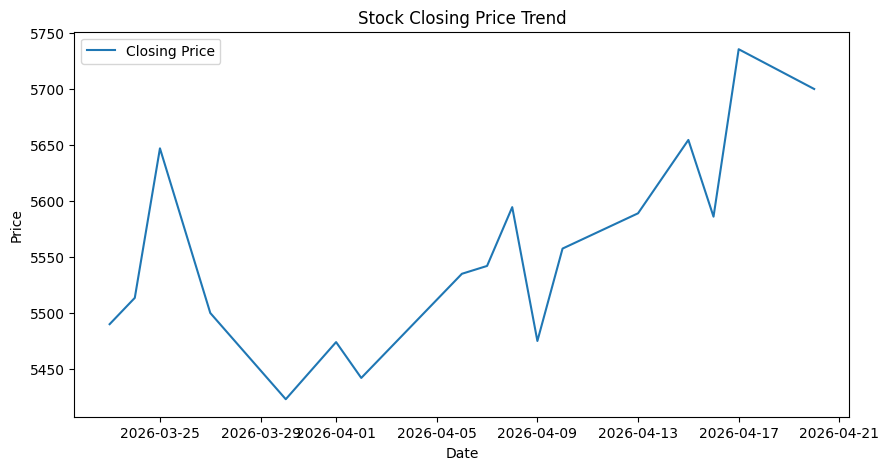

In [10]:
df['CLOSE'] = df['CLOSE'].str.replace(',', '').astype(float)
plt.figure(figsize=(10,5))
plt.plot(df['CLOSE'], label='Closing Price')
plt.title('Stock Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['CLOSE'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 4.822214200864233
p-value: 1.0


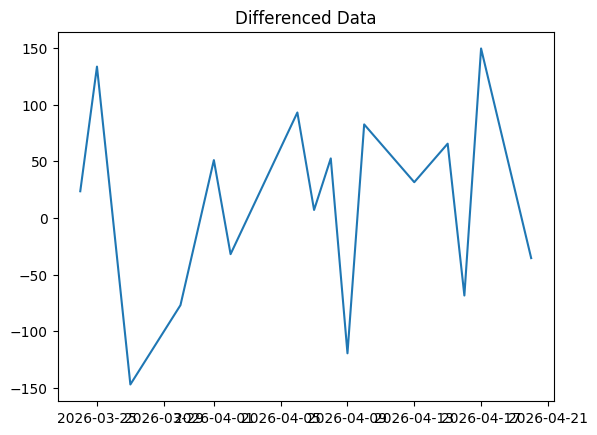

In [14]:
df_diff = df['CLOSE'].diff().dropna()

plt.plot(df_diff)
plt.title("Differenced Data")
plt.show()

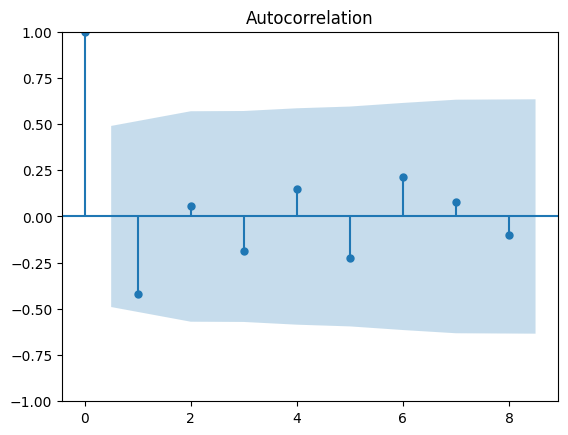

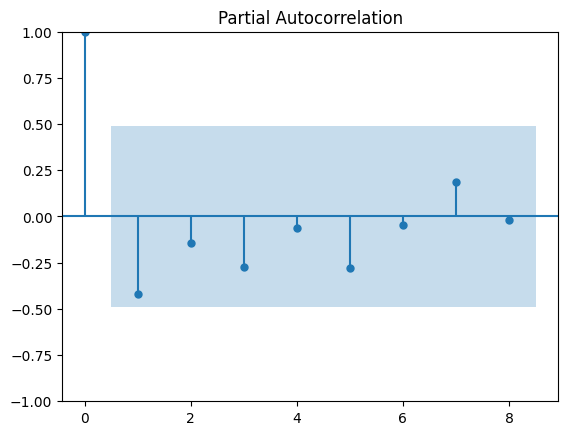

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff)
plot_pacf(df_diff)
plt.show()

In [16]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['CLOSE'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                   17
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -92.417
Date:                Tue, 21 Apr 2026   AIC                            190.834
Time:                        08:32:37   BIC                            193.151
Sample:                             0   HQIC                           190.952
                                 - 17                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0940      0.541      0.174      0.862      -0.966       1.154
ma.L1         -0.5284      0.528     -1.001      0.317      -1.563       0.506
sigma2      5894.6347   2875.116      2.050      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [17]:
forecast = model_fit.forecast(steps=30)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


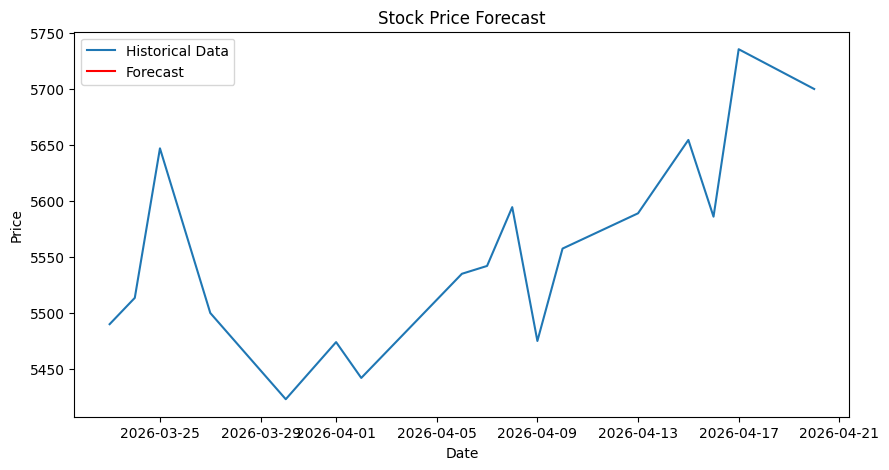

In [22]:
# Create future dates
future_dates = pd.date_range(start=df.index[-1], periods=30, freq='D')

# Convert forecast into Series with correct index
forecast_series = pd.Series(forecast, index=future_dates)

# Plot again
plt.figure(figsize=(10,5))
plt.plot(df['CLOSE'], label='Historical Data')
plt.plot(forecast_series, label='Forecast', color='red')
plt.title('Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [24]:
plt.savefig("forecast.png")

plt.show()

<Figure size 640x480 with 0 Axes>

In [25]:
from google.colab import files
files.download('forecast.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>